In [ ]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/EM_analyzer')
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/EM_analyzer/plot')
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as C
from plot.plot_basic import savefig
from plot.plot_1D import plot_multiple_1D_fields
from EM_analyzer.read_write import read_nc
from plot.plot_2D import generate_side_panel_axes,plot_multiple_2D_fields,plot_2D_field,plot_polar_field,plot_quiver_field

In [ ]:
theta_degree=45
theta_rad=np.radians(theta_degree)

laser_lambda = 0.875*C.micron		# Laser wavelength
laser_f0=1/laser_lambda
laser_k0=2*C.pi*laser_f0
laser_omega0=(2*C.pi*C.speed_of_light)/(laser_lambda)
laser_period=laser_lambda/C.speed_of_light
laser_a0=1		# Laser field strength
laser_Bc=(C.m_e*laser_omega0)/(C.elementary_charge)
laser_Ec=laser_Bc*C.speed_of_light   #4.013376e+12V/m
laser_Sc=C.epsilon_0*C.speed_of_light*laser_Ec**2/2   #1.327e+18 W/m^2
laser_amp=laser_a0*laser_Ec
laser_FWHM=8*C.femto   #The full width at half maximum of the intensity.
laser_tau=laser_FWHM/np.sqrt(2*np.log(2)) 
#laser_tau=laser_period/jnp.sqrt(jnp.pi)
laser_Nc=laser_omega0**2*C.m_e*C.epsilon_0/C.elementary_charge**2
laser_S0=C.epsilon_0*C.speed_of_light*laser_amp**2/2   #average Poynting vector

target_N=200

cells_per_lambda =2000
vacuum_length_x_lambda=20   #lambda
continuation_length_lambda=2000   #lambda
space_length_lambda=vacuum_length_x_lambda+2*continuation_length_lambda   #lambda
n_field_x=round(vacuum_length_x_lambda*cells_per_lambda)
n_continuation_x=round(space_length_lambda*cells_per_lambda)

d_x=laser_lambda/cells_per_lambda   #unit: m
d_f=1/(space_length_lambda*laser_lambda)   #unit: 1/m, d_x*d_f=1/n_continuation_x

print('λ0/dx=',laser_lambda/d_x)
print('f0/df=',laser_f0/d_f)

laser_lambda_M=laser_lambda/np.cos(theta_rad)
laser_period_M=laser_period/np.cos(theta_rad)
laser_tau_M=laser_tau/np.cos(theta_rad)
laser_f0_M=laser_f0*np.cos(theta_rad)
laser_k0_M=laser_k0*np.cos(theta_rad)
laser_Bc_M=laser_Bc*np.cos(theta_rad)
laser_Ec_M=laser_Ec*np.cos(theta_rad)
laser_Sc_M=laser_Sc*np.cos(theta_rad)**2
laser_Nc_M=laser_Nc/np.cos(theta_rad)
laser_amp_M=laser_amp*np.cos(theta_rad)
laser_S0_M=laser_S0*np.cos(theta_rad)**2
vacuum_length_x_lambda_M=vacuum_length_x_lambda*np.cos(theta_rad)
space_length_lambda_M=space_length_lambda*np.cos(theta_rad)   #laser_f0_M/d_f

laser_spectrum_peak_M=laser_amp_M*(np.sqrt(C.pi)/2)*(laser_tau_M*C.speed_of_light)*(1-np.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2))
laser_energy_M=laser_amp_M**2*np.sqrt(C.pi/2)*(laser_tau_M*C.speed_of_light/2)*(1-np.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2/2))
laser_envelope_integral_M=laser_amp_M**2*(laser_tau_M*C.speed_of_light)*np.sqrt(C.pi/2)

plasma_cutoff_order=np.sqrt(target_N/(np.cos(theta_rad))**3)

highest_harmonic=100000

λ0/dx= 2000.0
f0/df= 4020.0000000000005


In [9]:
working_dir='/scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/L+D=0.2/L_front=0.05,L_rear=0.05'
data_M_dict=read_nc(nc_name=os.path.join(working_dir,'Poynting_Vector_[3,+∞]_M_Frame.nc'),key_name_list=['Sx', 'Sy', 'Sz'])
#data_L_dict=read_nc(nc_name=os.path.join(working_dir,'Summarize_Field_L_Frame.nc'),key_name_list=['Jx_e', 'Jy_e', 'N_e'])



Read /scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/L+D=0.2/L_front=0.05,L_rear=0.05/Poynting_Vector_[3,+∞]_M_Frame.nc
Available keys: ['Sx', 'Sy', 'Sz']
Coordinates:
  * time     (time) float64 56kB 8.756e-15 8.762e-15 ... 4.961e-14 4.961e-14
  * x        (x) float64 240kB -2.625e-06 -2.625e-06 ... 2.625e-06 2.625e-06
time: <xarray.DataArray 'time' (time: 7000)> Size: 56kB
array([8.756349e-15, 8.761895e-15, 8.767995e-15, ..., 4.960064e-14,
       4.960619e-14, 4.961229e-14], shape=(7000,))
Coordinates:
  * time     (time) float64 56kB 8.756e-15 8.762e-15 ... 4.961e-14 4.961e-14
Attributes:
    units:      s
    long_name:  Time Coordinate in M Frame
x: <xarray.DataArray 'x' (x: 30000)> Size: 240kB
array([-2.624912e-06, -2.624737e-06, -2.624562e-06, ...,  2.624563e-06,
        2.624738e-06,  2.624913e-06], shape=(30000,))
Coordinates:
  * x        (x) float64 240kB -2.625e-06 -2.625e-06 ... 2.625e-06 2.625e-06
Attributes:
    units:      m
    long_name:  X Coordinate in M Frame
Data va

In [10]:
Sx=data_M_dict['Sx']
Sy=data_M_dict['Sy']
Sz=data_M_dict['Sz']
time_coordinate = data_M_dict['time']
x_coordinate = data_M_dict['x']
#Jx=data_L_dict['Jx_e']
#Jy=data_L_dict['Jy_e']
#Ne=data_L_dict['N_e']
print(np.max(Sx)/laser_Sc_M)
print(np.min(Sx)/laser_Sc_M)
print(time_coordinate[-2]/laser_period_M)

0.28570774721252634
-0.47341686117262
12.018036350541493


figure size= [21.16916219 14.        ] inch
ax_main position= Bbox(x0=0.21257336303312568, y0=0.32142857142857145, x1=0.7165688492891659, y1=0.8928571428571428)


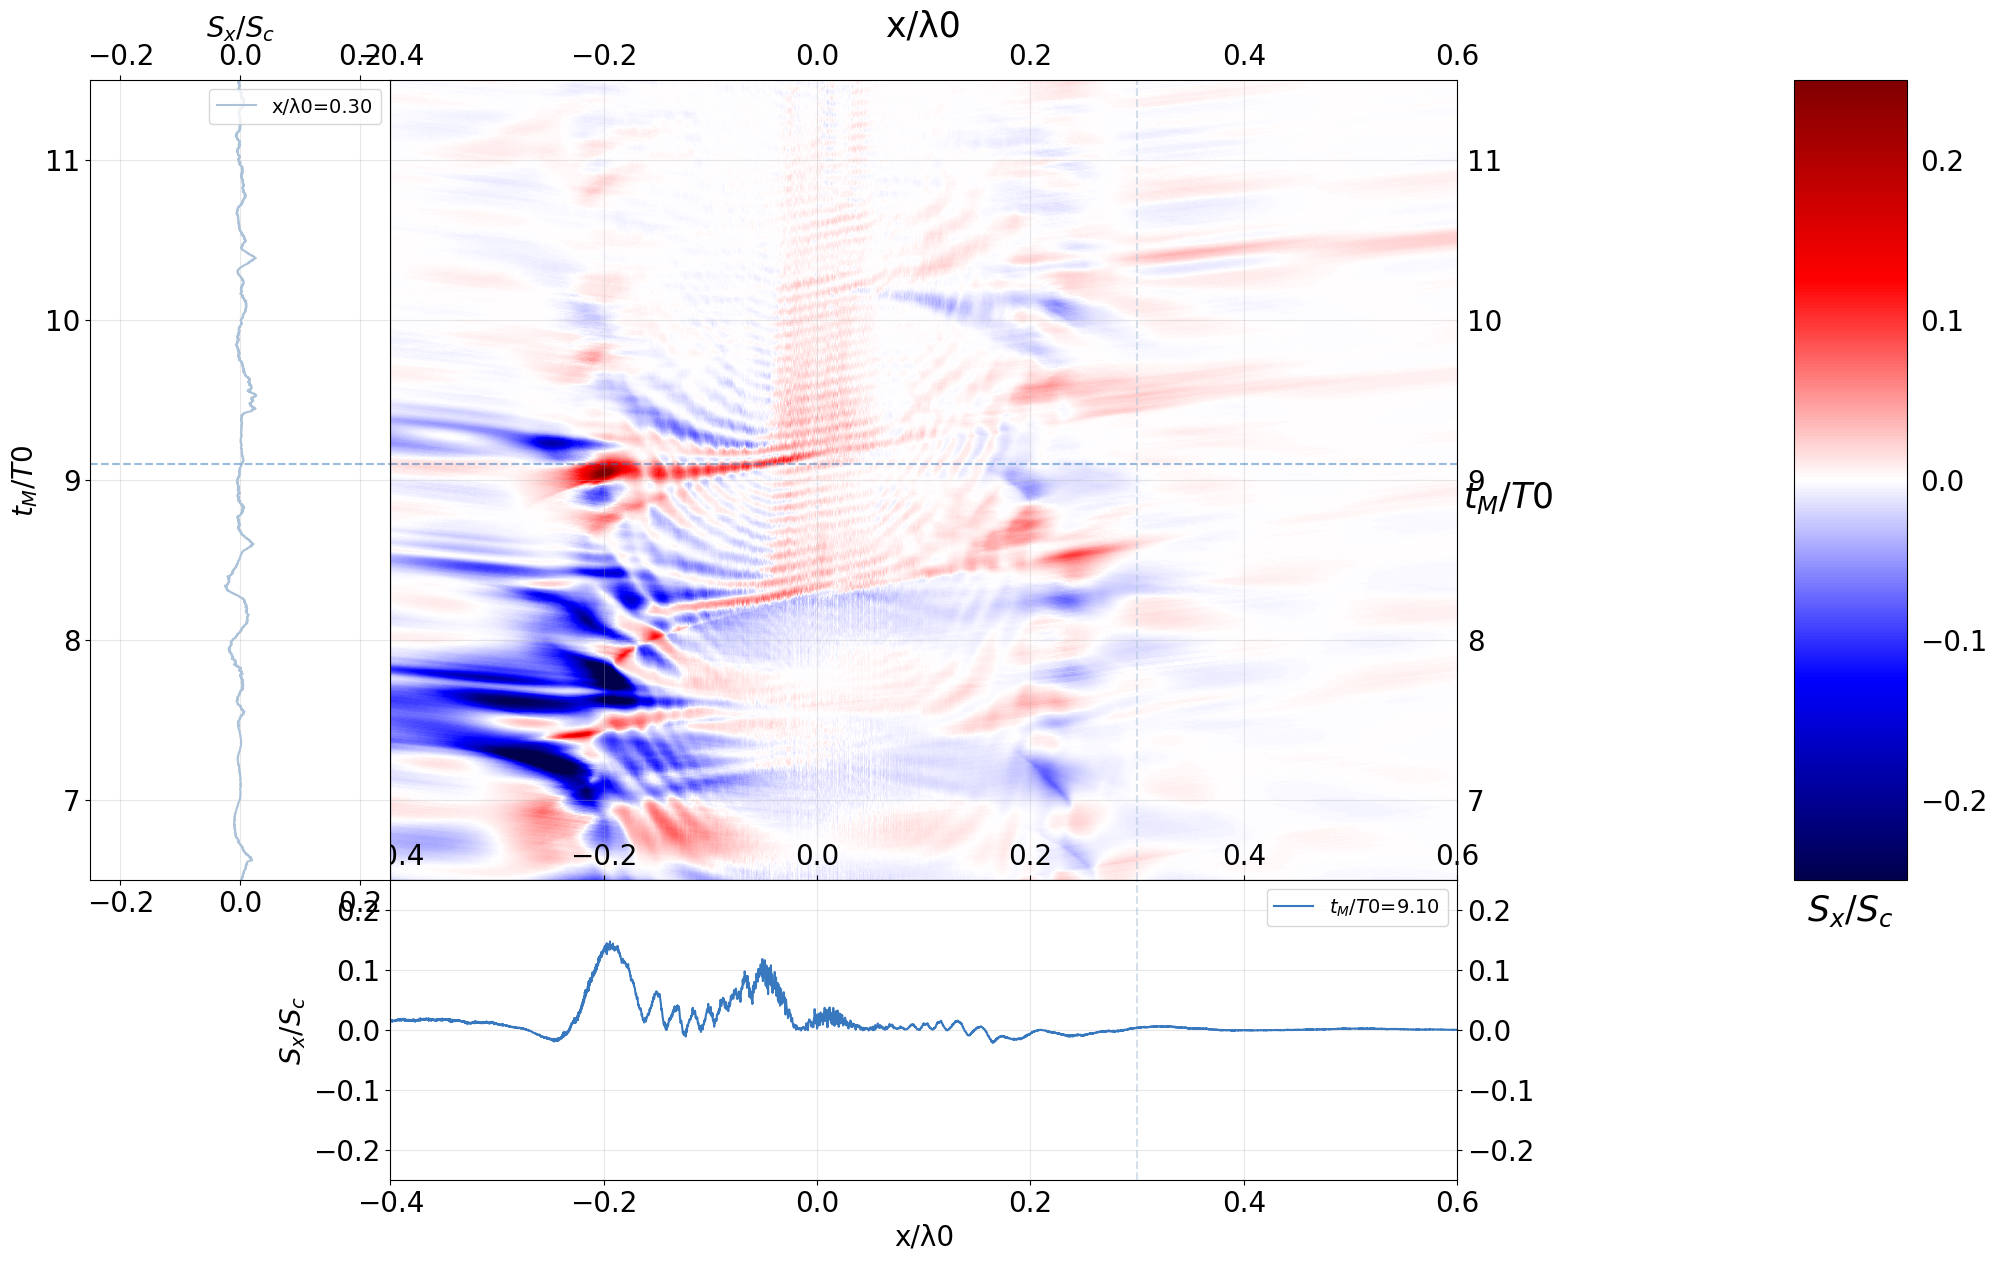

In [13]:
ax_dict=plot_2D_field(
    field=Sx.T/laser_Sc_M,
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    aspect=0.15,
    xmin=-0.4,xmax=0.6,ymin=6.5,ymax=11.5,
    vmin=-0.25,vmax=0.25,scale='linear',
    label=r'$S_x/S_c$',xlabel='x/λ0',ylabel=r'$t_M/T0$',
    profile_at_x=0.3,
    profile_at_y=9.1,ax_profile_y_at='bottom',
)

figure size= [15.83333883 14.        ] inch
ax_main position= Bbox(x0=0.28421042773154354, y0=0.10714285714285714, x1=0.6210527630246087, y1=0.6785714285714285)
Auto scale for quiver: 200.000


{'fig': <Figure size 1583.33x1400 with 7 Axes>,
 'ax_main': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x147aa4151be0>}

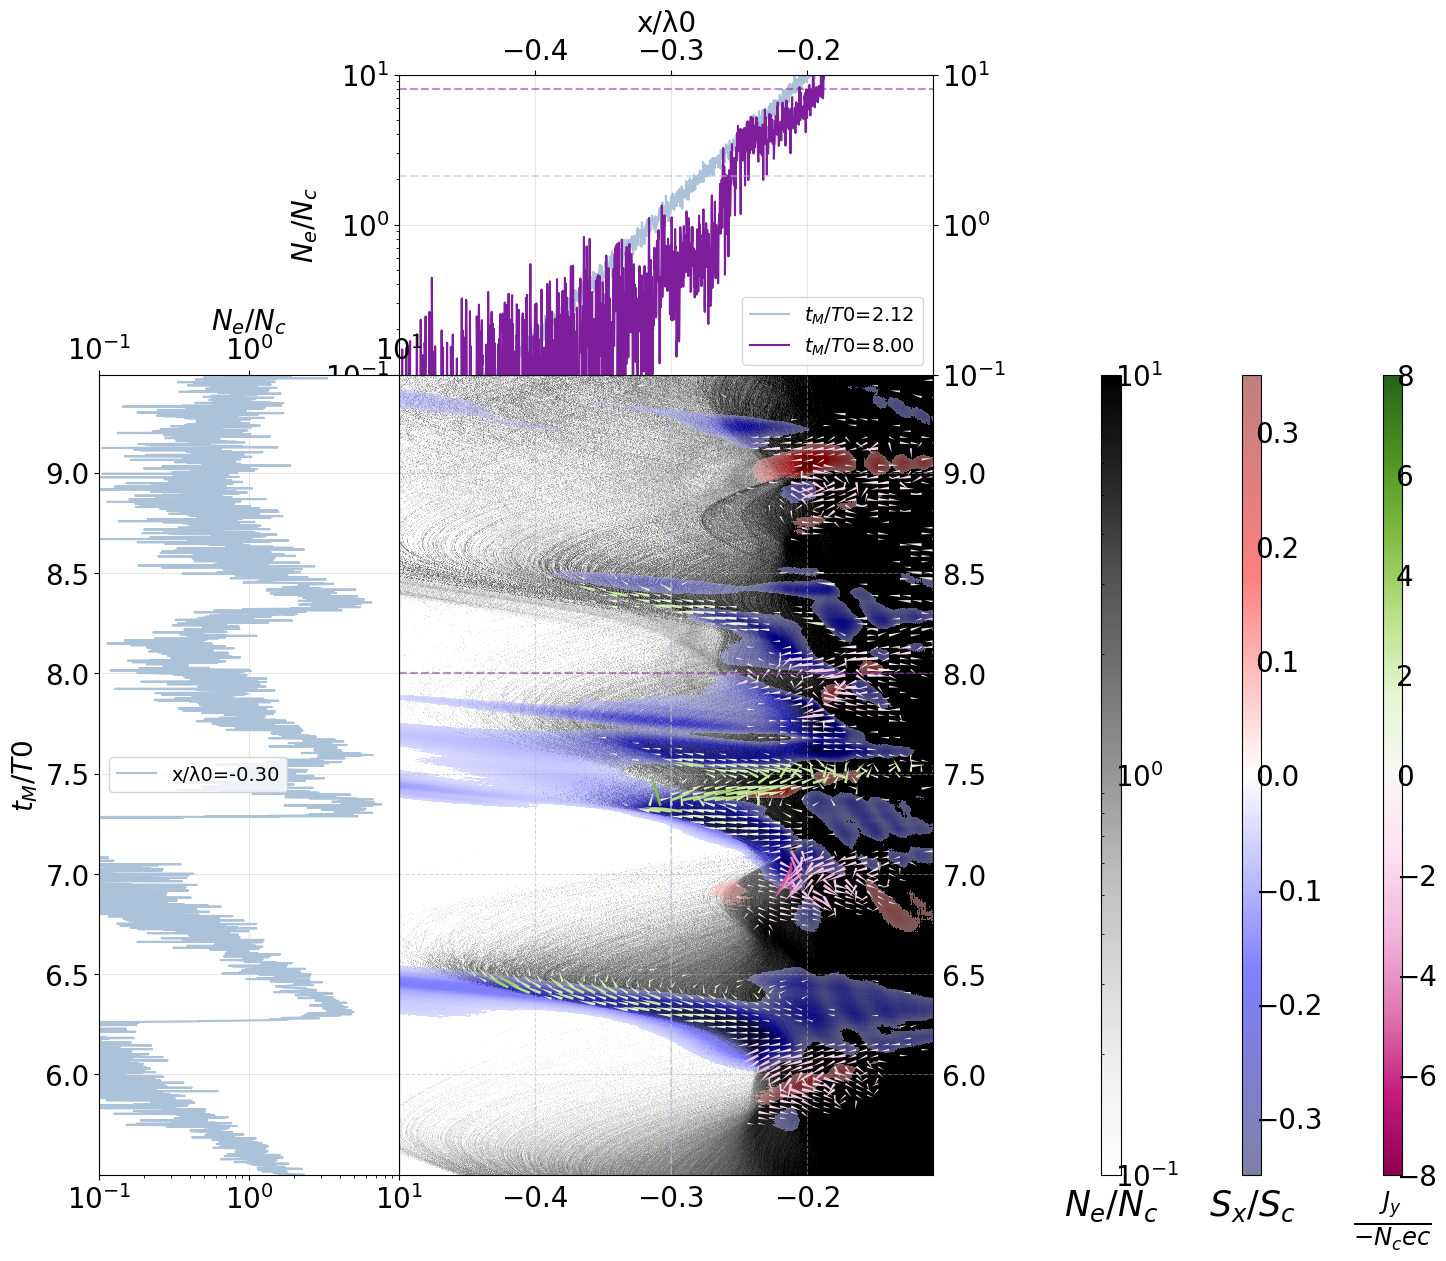

In [5]:

#ax_dict=generate_side_panel_axes(generate_ax_panel_left=True,generate_ax_panel_right=False,generate_ax_panel_top=True,generate_ax_panel_bottom=True)



ax_dict=plot_2D_field(
    field=Ne.T/laser_Nc,
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    aspect=0.15,
    xmin=-0.5,xmax=-0.1,ymin=5.5,ymax=9.5,
    vmin=0.1,vmax=10,scale='log',cmap='Grays',threshold=0.01,
    profile_at_x=-0.3,profile_at_y=[0,8],
    label=r'$N_e/N_c$',xlabel='x/λ0',ylabel=r'$t_M/T0$',
)
ax_dict=plot_2D_field(
    field=Sx.T/laser_Sc_M,
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    aspect=0.15,
    xmin=-0.5,xmax=-0.1,ymin=5.5,ymax=9.5,
    vmin=-0.35,vmax=0.35,scale='linear',threshold=0.05,
    label=r'$S_x/S_c$',
    alpha=0.5,
    plot_profile_x=False,plot_profile_y=False,profile_at_y=8,ax_profile_y_at='bottom',
    ax_dict=ax_dict,
)
plot_quiver_field(
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    Vx=Jx.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),Vy=Jy.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),
    B=Jy.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),
    step_x=40,step_y=20,
    xmin=-0.5,xmax=-0.1,ymin=5.5,ymax=9.5,
    threshold=1,scale=200,aspect=0.15,Bmin=-8,Bmax=8,
    cmap='PiYG',
    label=r'$\frac{J_y}{-N_c e c}$',
    ax_dict=ax_dict,
    )



figure size= [18.70569041 14.        ] inch
ax_main position= Bbox(x0=0.24056850627700355, y0=0.10714285714285714, x1=0.6792419916306619, y1=0.6785714285714285)
Auto scale for quiver: 50.000


{'fig': <Figure size 1870.57x1400 with 7 Axes>,
 'ax_main': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x1477e206b050>}

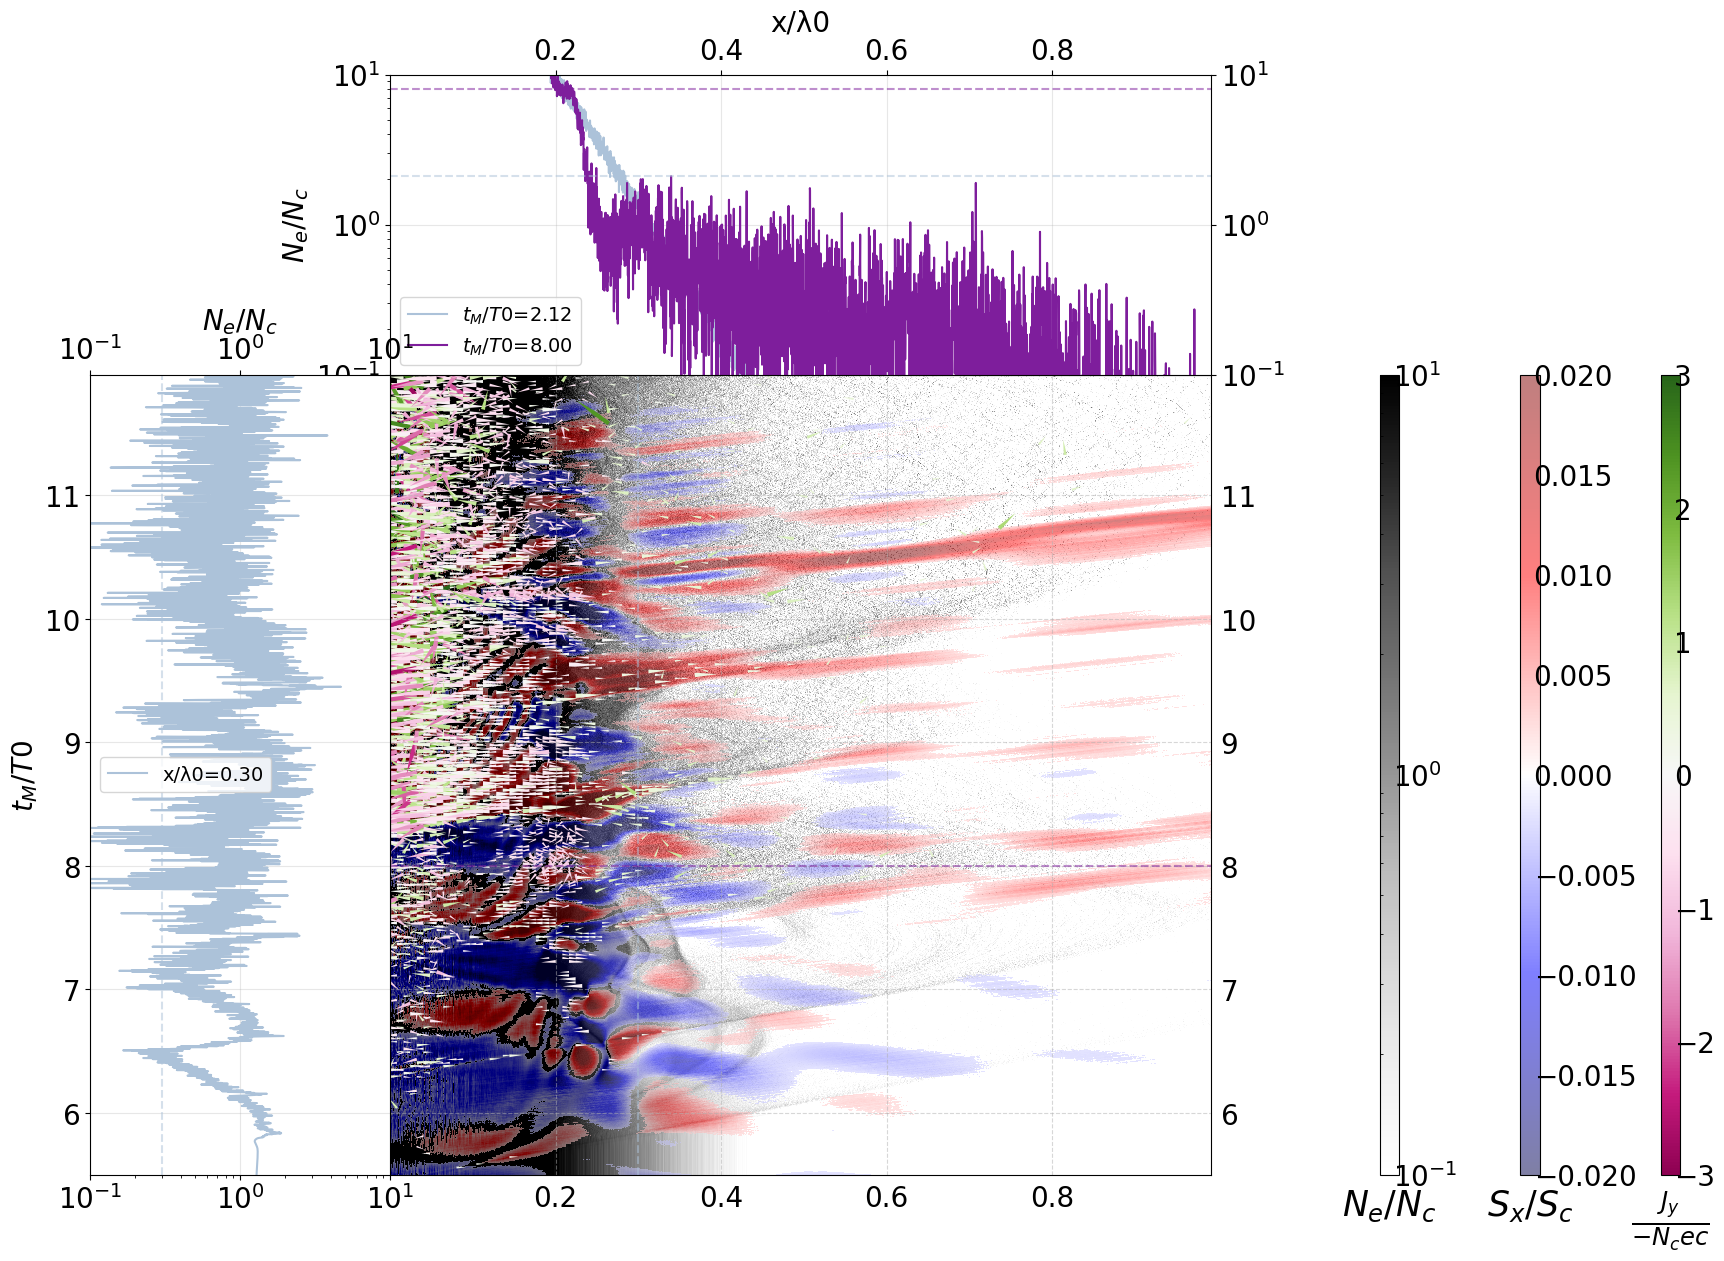

In [21]:
ax_dict=plot_2D_field(
    field=Ne.T/laser_Nc,
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    aspect=0.15,
    xmin=0,xmax=1,ymin=5.5,ymax=12,
    vmin=0.1,vmax=10,scale='log',cmap='Grays',threshold=0.01,
    profile_at_x=0.3,profile_at_y=[0,8],
    label=r'$N_e/N_c$',xlabel='x/λ0',ylabel=r'$t_M/T0$',
)
ax_dict=plot_2D_field(
    field=Sx.T/laser_Sc_M,
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    aspect=0.15,
    xmin=0,xmax=1,ymin=5.5,ymax=12,
    vmin=-0.02,vmax=0.02,scale='linear',threshold=0.002,
    label=r'$S_x/S_c$',
    alpha=0.5,
    plot_profile_x=False,plot_profile_y=False,profile_at_y=8,ax_profile_y_at='bottom',
    ax_dict=ax_dict,
)
plot_quiver_field(
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    Vx=Jx.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),Vy=Jy.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),
    B=Jy.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),
    step_x=40,step_y=20,
    xmin=0,xmax=1,ymin=5.5,ymax=12,
    threshold=0.5,
    scale=50,
    aspect=0.15,Bmin=-3,Bmax=3,
    cmap='PiYG',
    label=r'$\frac{J_y}{-N_c e c}$',
    ax_dict=ax_dict,
    )



figure size= [15.46488238  9.        ] inch
ax_main position= Bbox(x0=0.0969939481940949, y0=0.16666666666666666, x1=0.6120242072236204, y1=0.8333333333333333)
Auto scale for quiver: 400.000


{'fig': <Figure size 1546.49x900 with 3 Axes>,
 'ax_main': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x1477ee2b6490>}

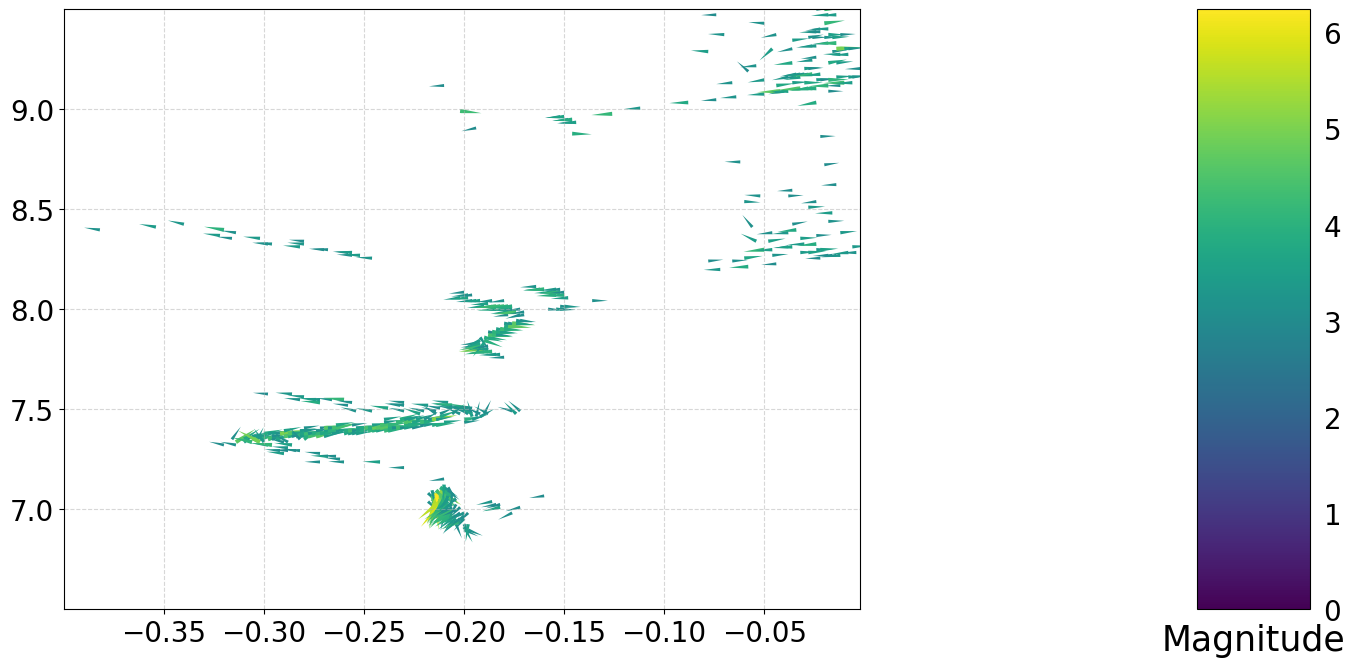

In [7]:
plot_quiver_field(
    x_coordinate=x_coordinate/laser_lambda,y_coordinate=time_coordinate/laser_period_M,
    Vx=Jx.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),Vy=Jy.T/(-laser_Nc*C.speed_of_light*C.elementary_charge),
    step_x=10,step_y=10,aspect=0.1,
    xmin=-0.4,xmax=0,ymin=6.5,ymax=9.5,
    threshold=3,scale=400,
    )